<a href="https://colab.research.google.com/github/gyumin125/25-2-DIP-202302456/blob/main/HW/HW06.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Image Restoration

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
from google.colab import drive
drive.mount('/content/drive')
imgpath = '/content/drive/MyDrive/DIP4E'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Exercise
- 두 개의 noisy image를 각각 f1, f2로 불러오고 적절한 restoration(denoising)을 수행해보자.

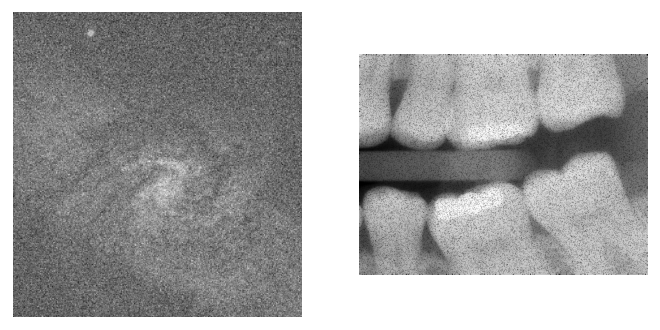

In [3]:
f1 = plt.imread(imgpath+'/galaxy-pair-noisy.tif')
f2 = plt.imread(imgpath+'/dentalXray-pepper-noise.tif')

plt.figure(dpi=128)
plt.subplot(121)
plt.imshow(f1,cmap='gray')
plt.axis('off')
plt.subplot(122)
plt.imshow(f2,cmap='gray')
plt.axis('off')
plt.show()

- 복원코드를 직접 작성해보기.

In [4]:
std_eta = 20
SS = 7 # kernel size (square kernel)
ss = int((SS-1)/2)
r_median1 = np.zeros(np.shape(f1))
r_mean1 = np.zeros(np.shape(f1))
r_amean1 = np.zeros(np.shape(f1)) # Initialize r_amean1
r_median2 = np.zeros(np.shape(f2))
r_mean2 = np.zeros(np.shape(f2))
r_amean2 = np.zeros(np.shape(f2)) # Initialize r_amean2

In [5]:
for x in range(ss,np.size(f1,0)-ss):
  for y in range(ss,np.size(f1,1)-ss):
    Sxy1 = f1[x-ss:x-ss+SS,y-ss:y-ss+SS]
    r_mean1[x,y] = np.mean(Sxy1)
    r_median1[x,y] = np.median(Sxy1)
    std_Sxy1 = np.std(Sxy1)
    r_amean1[x,y]=f1[x,y]-((std_eta*std_eta)/(std_Sxy1*std_Sxy1))*(f1[x,y]-np.mean(Sxy1))

In [6]:
for x in range(ss,np.size(f2,0)-ss):
  for y in range(ss,np.size(f2,1)-ss):
    Sxy2 = f2[x-ss:x-ss+SS,y-ss:y-ss+SS]
    r_mean2[x,y] = np.mean(Sxy2)
    r_median2[x,y] = np.median(Sxy2)
    std_Sxy2 = np.std(Sxy2)
    r_amean2[x,y]=f2[x,y]-((std_eta*std_eta)/(std_Sxy2*std_Sxy2))*(f2[x,y]-np.mean(Sxy2))

/tmp/ipython-input-2049517231.py:7: RuntimeWarning: divide by zero encountered in scalar divide
  r_amean2[x,y]=f2[x,y]-((std_eta*std_eta)/(std_Sxy2*std_Sxy2))*(f2[x,y]-np.mean(Sxy2))
/tmp/ipython-input-2049517231.py:7: RuntimeWarning: invalid value encountered in scalar multiply
  r_amean2[x,y]=f2[x,y]-((std_eta*std_eta)/(std_Sxy2*std_Sxy2))*(f2[x,y]-np.mean(Sxy2))


In [7]:
def f_myadaptive(g):
    M,N = g.shape
    f = np.empty_like(g)
    kmax=9
    rmax = kmax // 2
    padded = np.pad(g, pad_width=rmax, mode='constant',constant_values=0)


    for y in range(M):
        for x in range(N):
            z_xy = padded[y + rmax, x + rmax]
            k = 1
            while True:
                y0, y1 = y + rmax - k, y + rmax + k + 1
                x0, x1 = x + rmax - k, x + rmax + k + 1
                kernel = padded[y0:y1, x0:x1]

                z_min = kernel.min()
                z_med = np.median(kernel)
                z_max = kernel.max()

                if (z_min<z_med) and (z_med<z_max):
                    if (z_min < z_xy) and (z_xy < z_max):
                        f[y, x] = z_xy
                    else:
                        f[y, x] = z_med
                    break
                else:
                    k += 1
                    if k > rmax:
                         f[y, x] = z_med
                         break


    return f

In [8]:
r_adapt1 = f_myadaptive(f1)
r_adapt2 = f_myadaptive(f2)

- 복원된 f1, f2를 시각화하기

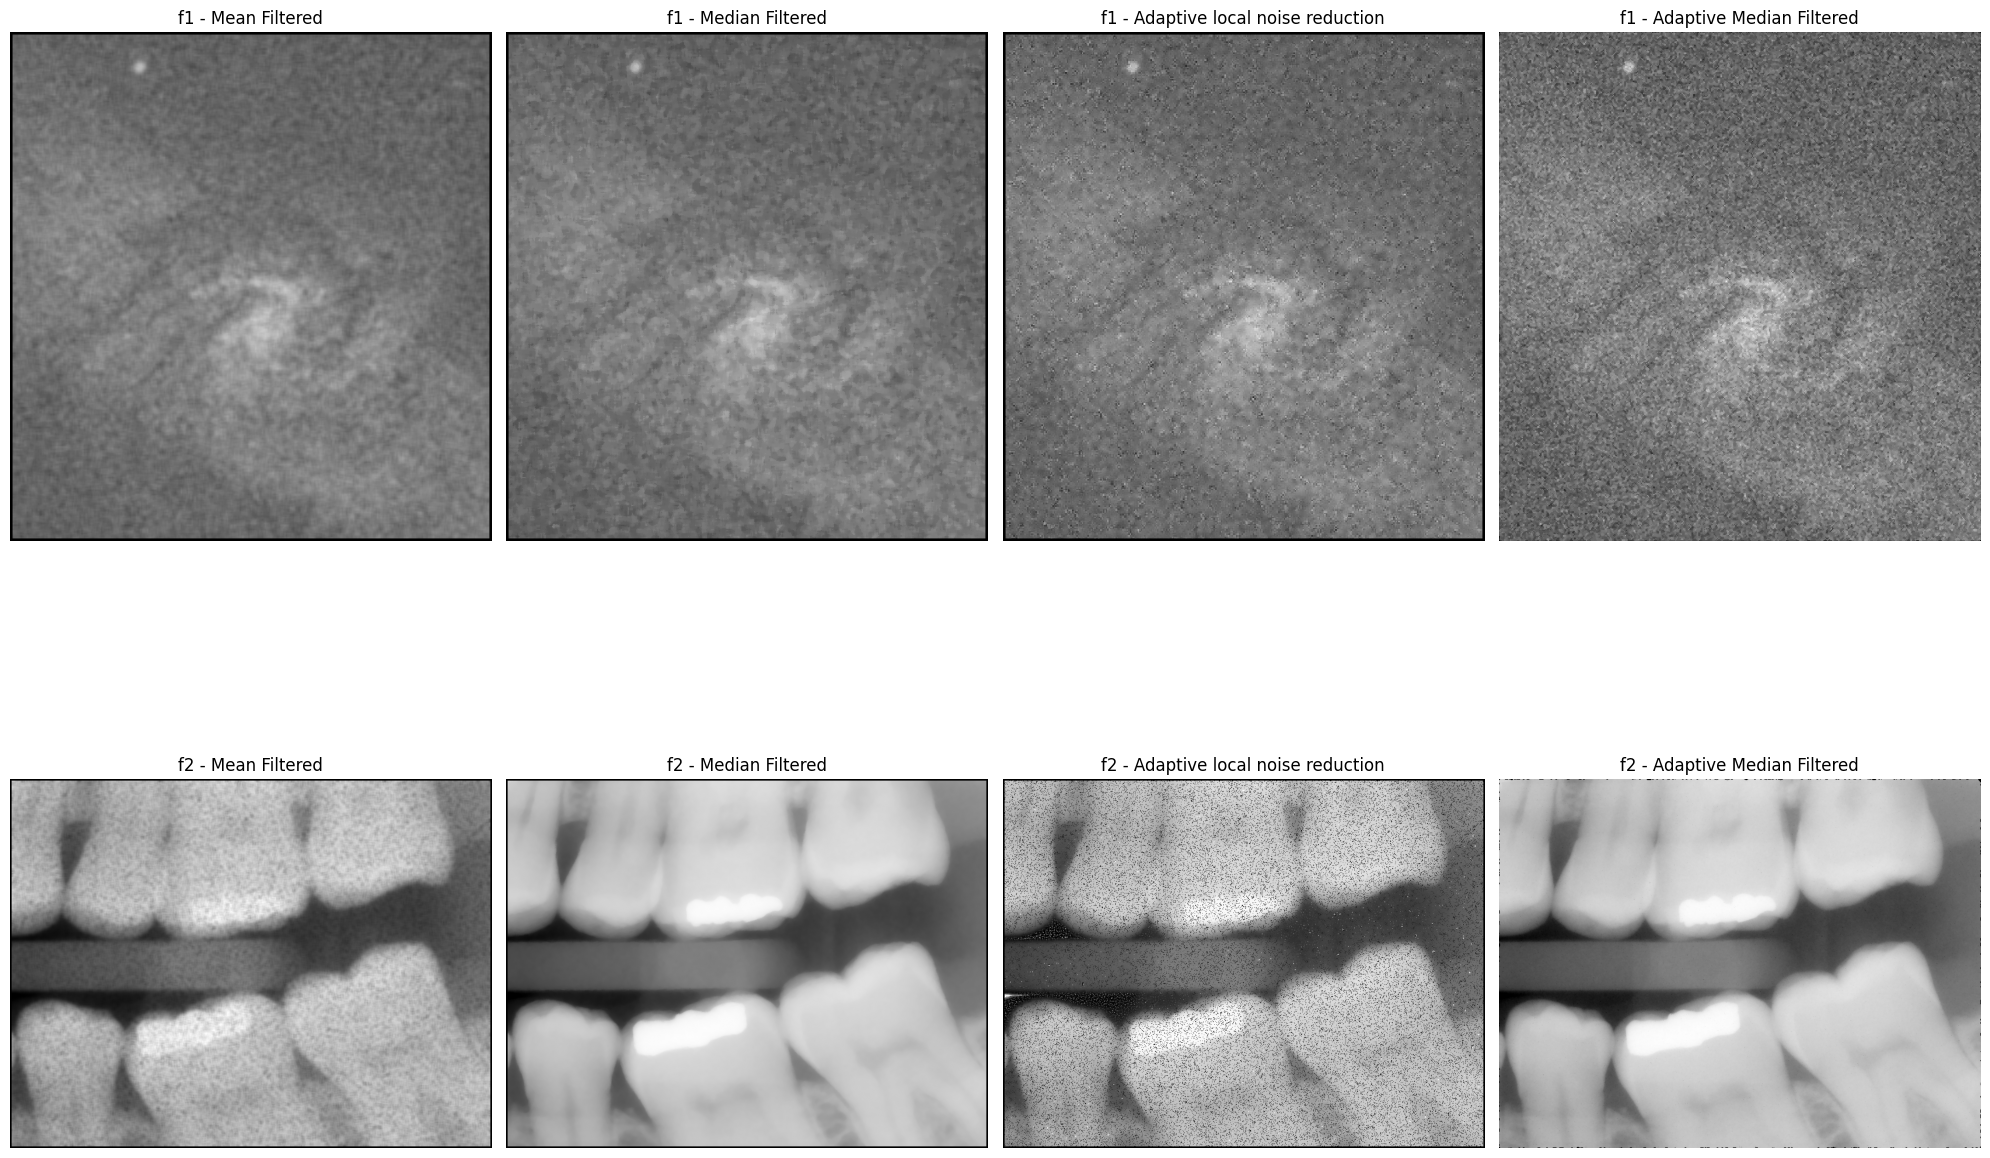

In [12]:
plt.figure(figsize=(20, 16))

plt.subplot(2, 4, 1)
plt.imshow(r_mean1, cmap='gray', aspect='equal', vmin=0, vmax=255)
plt.title('f1 - Mean Filtered')
plt.axis('off')

plt.subplot(2, 4, 2)
plt.imshow(r_median1, cmap='gray', aspect='equal', vmin=0, vmax=255)
plt.title('f1 - Median Filtered')
plt.axis('off')

plt.subplot(2, 4, 3)
plt.imshow(r_amean1, cmap='gray', aspect='equal', vmin=0, vmax=255)
plt.title('f1 - Adaptive local noise reduction')
plt.axis('off')

plt.subplot(2, 4, 4)
plt.imshow(r_adapt1, cmap='gray', aspect='equal', vmin=0, vmax=255)
plt.title('f1 - Adaptive Median Filtered')
plt.axis('off')

plt.subplot(2, 4, 5)
plt.imshow(r_mean2, cmap='gray', aspect='equal', vmin=0, vmax=255)
plt.title('f2 - Mean Filtered')
plt.axis('off')

plt.subplot(2, 4, 6)
plt.imshow(r_median2, cmap='gray', aspect='equal', vmin=0, vmax=255)
plt.title('f2 - Median Filtered')
plt.axis('off')

plt.subplot(2, 4, 7)
plt.imshow(r_amean2, cmap='gray', aspect='equal', vmin=0, vmax=255)
plt.title('f2 - Adaptive local noise reduction')
plt.axis('off')

plt.subplot(2, 4, 8)
plt.imshow(r_adapt2, cmap='gray', aspect='equal', vmin=0, vmax=255)
plt.title('f2 - Adaptive Median Filtered')
plt.axis('off')

plt.tight_layout()
plt.show()

- 적절한 denoising으로 복원된 f1, f2를 시각화하기

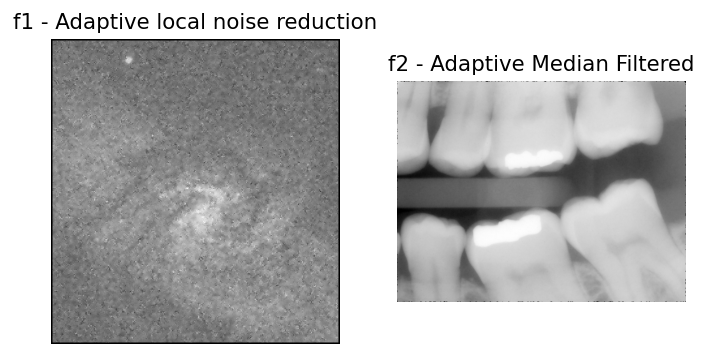

In [13]:
# f1_r: denoised f1
# f2_r: denoised f2
plt.figure(dpi=128)
plt.subplot(121)
plt.imshow(r_amean1,cmap='gray')
plt.title('f1 - Adaptive local noise reduction')
plt.axis('off')
plt.subplot(122)
plt.imshow(r_adapt2,cmap='gray')
plt.title('f2 - Adaptive Median Filtered')
plt.axis('off')
plt.show()

- 복원된 f1, f2를 그림파일로 저장하기

In [14]:
plt.imsave('denoised-galaxy-pair.png',r_amean1,cmap='gray')
plt.imsave('denoised-dentalXray.png',r_adapt2,cmap='gray')